# Ranking the three loss variants by interval quality, not RMSE

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, wilcoxon
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks_2" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from azt1d import loading, plotting
from azt1d.glimmer import checkpoint as ckpt
from azt1d.glimmer import uncertainty as unc

plotting.apply_style()
pd.set_option("display.max_columns", None)

CKPT_ROOT = PROJECT_ROOT / "data" / "processed" / "checkpoints"
MODELS = {
    "No error weighted": ("cnn_lstm_v0", plotting.CATEGORICAL[0]),
    "Standard error weighted": ("cnn_lstm_v1", plotting.CATEGORICAL[1]),
    "Personalized": ("cnn_lstm_v3_tuned", plotting.CATEGORICAL[2]),
}

df = loading.load_real_dataset(PROJECT_ROOT / "data" / "raw", PROJECT_ROOT / "data" / "processed")
subject_ids = sorted(int(s) for s in df["subject_id"].unique())

In [2]:
# One BandEngine per (patient, model), fitted on GARCH only -- the same method used in
# notebooks_2/02 and notebooks_3/01, so this stays comparable to those. Nothing here is
# fitted on the test period: forecast_frames splits validation from test, and the engine
# only ever calibrates on validation residuals.
rows = []
engines, frames = {}, {}
max_gap = 0.0
for name, (run, _) in MODELS.items():
    for sid in subject_ids:
        res = ckpt.load_result(CKPT_ROOT / run, sid)
        df_subject = df[df["subject_id"] == sid].reset_index(drop=True)
        val, test = unc.forecast_frames(res, df_subject)
        max_gap = max(max_gap, unc.matches_stored_predictions(test, res))
        eng = unc.BandEngine(val, test, analogs=False)
        engines[(name, sid)] = eng
        frames[(name, sid)] = test
        auc = unc.trigger_auc(eng, test.actual, "GARCH")
        point = unc.trigger_metrics(test.actual, test.pred, test.pred)
        rows.append({"model": name, "subject_id": sid, "rmse": res.rmse, "val_rmse": res.val_rmse,
                     "interval_auc": auc, "point_false_trigger_rate": point["false_trigger_rate"],
                     "point_danger_caught": point["danger_caught"]})

assert max_gap < 0.05, "rebuilt predictions do not match the checkpoints"
table = pd.DataFrame(rows)
print(f"Rebuilt forecasts and bands for {len(subject_ids)} patients x {len(MODELS)} models. "
      f"Largest gap vs. saved checkpoint predictions: {max_gap:.6f} mg/dL")

Rebuilt forecasts and bands for 25 patients x 3 models. Largest gap vs. saved checkpoint predictions: 0.000000 mg/dL


## 1. Cohort summary: RMSE vs. interval AUC

In [3]:
summary = table.groupby("model")[["rmse", "interval_auc"]].agg(["mean", "std"])
summary.round(3)

rmse        interval_auc       
                           mean    std         mean    std
model                                                     
No error weighted        31.544  6.223        0.797  0.066
Personalized             41.123  6.436        0.730  0.087
Standard error weighted  41.184  6.003        0.731  0.072

In [4]:
def paired(a, b, col):
    """Wilcoxon signed-rank test on the per-patient difference, a minus b."""
    x = table[table.model == a].set_index("subject_id")[col]
    y = table[table.model == b].set_index("subject_id")[col]
    diff = (x - y).to_numpy()
    stat = wilcoxon(diff)
    return {"a - b (mean)": float(diff.mean()), "p-value": stat.pvalue}


pairs = [("Standard error weighted", "No error weighted"), ("Personalized", "Standard error weighted"),
         ("Personalized", "No error weighted")]
pd.DataFrame({f"{a} vs. {b}": {**{"metric": "interval_auc"}, **paired(a, b, "interval_auc")}
              for a, b in pairs}).T

,metric,a - b (mean),p-value
Standard error weighted vs. No error weighted,interval_auc,-0.066464,0.000007
Personalized vs. Standard error weighted,interval_auc,-0.000649,0.490786
Personalized vs. No error weighted,interval_auc,-0.067113,0.000001


In [5]:
pd.DataFrame({f"{a} vs. {b}": {**{"metric": "rmse"}, **paired(a, b, "rmse")}
              for a, b in pairs}).T

,metric,a - b (mean),p-value
Standard error weighted vs. No error weighted,rmse,9.639262,0.0
Personalized vs. Standard error weighted,rmse,-0.060671,0.578206
Personalized vs. No error weighted,rmse,9.578591,0.0


## 2. The danger-caught vs. false-trigger curve, pooled across patients

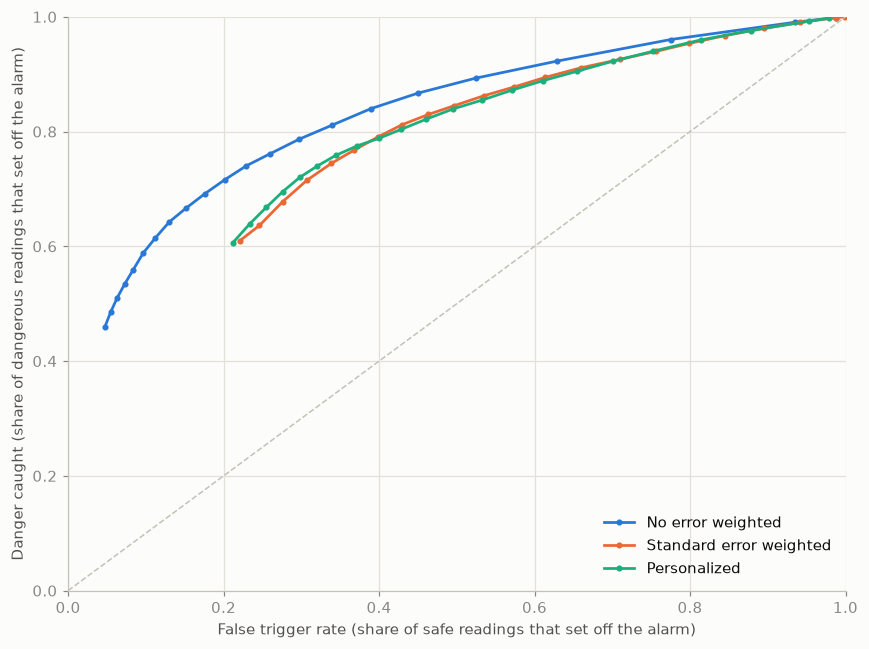

In [6]:
def pooled_bands(name, level):
    los, his = zip(*(engines[(name, s)].bands("GARCH", level) for s in subject_ids))
    return np.concatenate(los), np.concatenate(his)


actual_all = np.concatenate([frames[("No error weighted", s)].actual for s in subject_ids])
SWEEP = unc.DEFAULT_AUC_LEVELS

fig, ax = plt.subplots(figsize=(8, 6))
for name, (_, color) in MODELS.items():
    curve = [unc.trigger_metrics(actual_all, *pooled_bands(name, lv)) for lv in SWEEP]
    x = [c["false_trigger_rate"] for c in curve]
    y = [c["danger_caught"] for c in curve]
    ax.plot(x, y, color=color, linewidth=1.8, marker="o", markersize=3, label=name)
ax.plot([0, 1], [0, 1], color=plotting.BASELINE, linewidth=1, linestyle="--")
ax.set_xlabel("False trigger rate (share of safe readings that set off the alarm)")
ax.set_ylabel("Danger caught (share of dangerous readings that set off the alarm)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

## 3. RMSE rank vs. interval-AUC rank, per patient

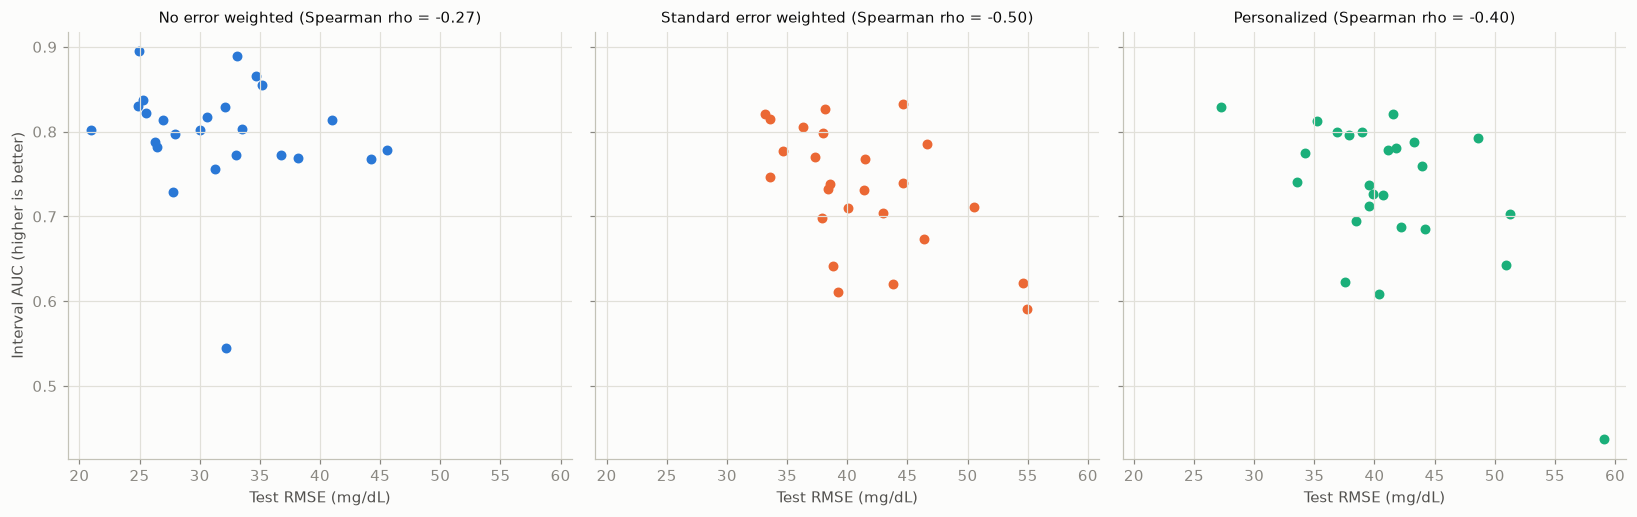

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)
for ax, (name, (_, color)) in zip(axes, MODELS.items()):
    sub = table[table.model == name]
    rho = spearmanr(sub.rmse, sub.interval_auc).statistic
    ax.scatter(sub.rmse, sub.interval_auc, color=color, s=30)
    ax.set_title(f"{name} (Spearman rho = {rho:.2f})", fontsize=10)
    ax.set_xlabel("Test RMSE (mg/dL)")
axes[0].set_ylabel("Interval AUC (higher is better)")
fig.tight_layout()
plt.show()

## 4. Per-patient interval AUC by model

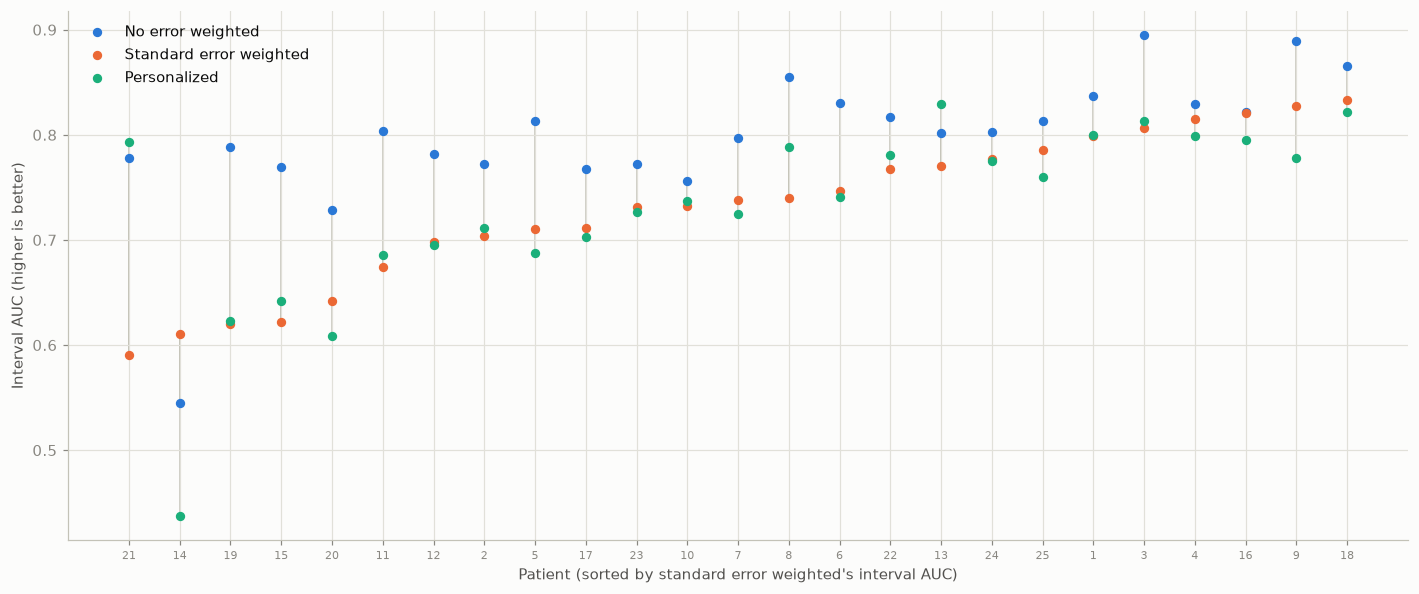

In [8]:
pivot = table.pivot(index="subject_id", columns="model", values="interval_auc")
pivot = pivot[list(MODELS)].sort_values("Standard error weighted")

fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(pivot))
for sid_x, (sid, row) in zip(x, pivot.iterrows()):
    ax.plot([sid_x] * len(MODELS), row.values, color=plotting.BASELINE, linewidth=1, zorder=1)
for name, (_, color) in MODELS.items():
    ax.scatter(x, pivot[name], color=color, s=26, label=name, zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, fontsize=7)
ax.set_xlabel("Patient (sorted by standard error weighted's interval AUC)")
ax.set_ylabel("Interval AUC (higher is better)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()